# Complainify AI — 11 · Live Heatmap & Pipeline

Companion notebook to the main *Complainify_AI_Study.ipynb*.

---
## 11: From Data to Dashboard — the live heatmap

Mirrors the admin page **Sentiment × Priority** (`/admin/analysis`): a category × priority heatmap for non-positive complaints, the green/positive counter-matrix, and the 'closed but still hurting' list (Resolved + Negative + High/Medium).

In [1]:
import os, sys, json, csv, math, random
from collections import Counter, defaultdict
BASE = r'E:\Project-VI\workspace\ComplaintMgmtSystem'
sys.path.insert(0, os.path.join(BASE, 'ml'))
random.seed(42)
sys.path.insert(0, os.path.join(BASE, 'ml'))
import gen_analysis
try:
    rows = gen_analysis.fetch_rows()
    a = gen_analysis.build_analysis(rows)
    a['rows'] = len(rows)
    print('live DB rows:', a['rows'])
except Exception as e:
    print('DB unavailable — fallback to cached JSON snapshot')
    a = json.load(open(os.path.join(BASE, 'data', 'live_analysis.json')))
print('sentiment totals:', a['sentiment_totals'])
print('priority totals :', a['priority_totals'])
print('pink (closed, still negative):', a.get('pink_total'))

live DB rows: 28
sentiment totals: {'Positive': 3, 'Neutral': 7, 'Negative': 18}
priority totals : {'Low': 5, 'Medium': 13, 'High': 10}
pink (closed, still negative): 3


### Heatmap render (same data the browser paints)

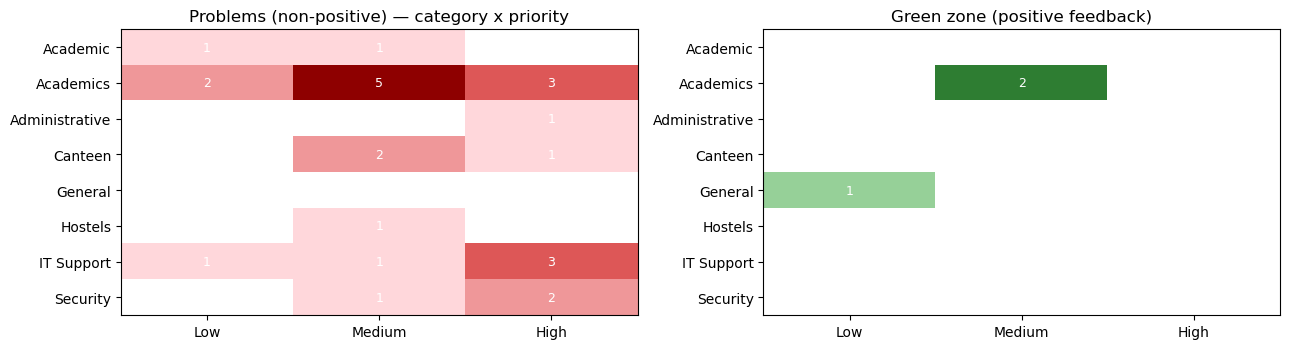

In [2]:
import pandas as pd
prios = ['Low', 'Medium', 'High']
def grid(key):
    d = a.get(key) or {}
    if not d: return None
    df = pd.DataFrame(d).T.reindex(columns=prios).fillna(0)
    return df if len(df) else None
df_red, df_grn = grid('matrix'), grid('green')
if df_red is not None:
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    red = LinearSegmentedColormap.from_list('red', ['#ffffff', '#ffcdd2', '#e57373', '#d32f2f', '#8e0000'])
    grn = LinearSegmentedColormap.from_list('grn', ['#ffffff', '#c8e6c9', '#66bb6a', '#2e7d32'])
    fig, axes = plt.subplots(1, 2, figsize=(13, max(3, len(df_red) * 0.45)))
    axes[0].imshow(df_red.values, cmap=red, aspect='auto')
    axes[1].imshow(df_grn.values, cmap=grn, aspect='auto')
    for ax, df, cmap in ((axes[0], df_red, 'white'), (axes[1], df_grn, 'white')):
        ax.set_xticks(range(3)); ax.set_xticklabels(prios)
        ax.set_yticks(range(len(df))); ax.set_yticklabels(df.index)
        for i in range(len(df)):
            for j in range(3):
                ax.text(j, i, int(df.values[i, j]), ha='center', va='center', color=cmap, fontsize=9)
    axes[0].set_title('Problems (non-positive) — category x priority')
    axes[1].set_title('Green zone (positive feedback)')
    plt.tight_layout(); plt.show()
else:
    print('no matrix data — nothing to plot yet')

### The live pipeline wiring

- `ml/env.py` lazy-loads `data/sentiment_model.json` + `data/priority_model.json` (from-scratch MultinomialNB).
- `ml/sentiment.py` and `ml/priority.py` consult it **first**, falling back to the old rules when the model is missing or unconfident — the web app keeps working even before training.
- `ml/gen_analysis.py` reads the MySQL `complaints` table; `/admin/analysis` renders the heatmaps live.
- The same numbers drive the report pages, so notebook, CLI, and dashboard never drift apart.